## RoPE position embeddings
In contrast to the GPT2 implementation where the position embeddings are learned, [Rotary Position Embedding (RoPE)](https://arxiv.org/abs/2104.09864) uses fixed equations for the positional embeddings. Also, GPT2 mixes positional and semantic embeddings by adding them together, RoPE instead separates out positional embeddings and applies them in the attention mechanism itself.
While the calculations introduced by RoPE are fairly straigh-forward, the intuition behind them are worth taking the time to [understand](https://towardsdatascience.com/rope-clearly-explained/).


RoPE works by rotating the $q$ and $k$ projections of each token. The amount of rotation applied depends on the absolute position $m$ of the token. Furthermore, rotation is applied non-uniformly across all the 2D pairs of vector indices, $i$, so that the first pairs of dimensions in the $q$ and $k$ vectors are rotated more than the final pairs of the vectors. This allows for specialiation as the first dimensions can primarily contribute to attention scores over shorter sequences, whereas the last dimensions can contribute even if they are remote in the sequence.

Each 2D pair is rotated by a predefined angle. The starting point is a set of angular values, $\Theta$, containing $P/2$ elements where $P$ is the per-head output dimension:
$$ \Theta = \{\theta_i = 10000^{−2(i−1)/d}, i \in [1,2,...,d/2]\} $$

For token position in the context window, a new set of angular values are generated by multiplying the orignal values by the token index. This approach ensures that nearby tokens are rotated by more similar angles than tokens further away in the seqeunce.  

The [Llama model implementation of RoPE](https://github.com/meta-llama/llama/blob/6c7fe276574e78057f917549435a2554000a876d/llama/model.py#L48) was helpful as a reference during this work.

My implementation of RoPE can be found [here](https://github.com/crs17/sturnus/blob/main/src/sturnus/models/rope.py).


In [ ]:
import torch

from sturnus.models.rope import calculate_thetas, apply_rope

B = 2
C = 200
H = 3
P = 100

torch.manual_seed(42)
q = torch.rand(B, C, H, P)
k = torch.rand(B, C, H, P)

c_values, thetas = calculate_thetas(embedding_dimension=P, context_size=C)

q_ = apply_rope(q, c_values)
k_ = apply_rope(k, c_values)

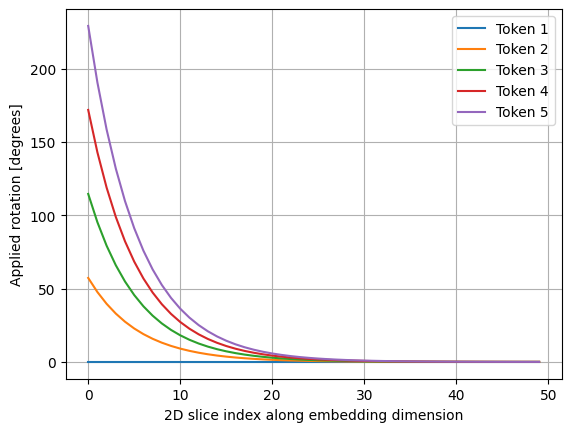

In [39]:
import matplotlib.pylab as plt


fig, ax = plt.subplots()

for i in range(0, 5):
    c_b = torch.view_as_real(c_values)[i,:]
    angle = torch.atan2(c_b[:, 1], c_b[:, 0]) * 180 / torch.pi
    angle[angle<0] += 360
    ax.plot(
        range(int(P/2)),
        angle,
        label=f'Token {i+1}'
    )
# ax.plot(thetas * 180 / torch.pi, '--', label='θ')

ax.set_xlabel('2D slice index along embedding dimension')
ax.set_ylabel('Applied rotation [degrees]')
ax.grid()
ax.legend()


Above we see the rotational angles applied to the first five tokens. We clearly see that the first dimensions in each $q$ and $k$ vector are rotated much more than the later dimensions as discussed above. We also see that the vectors of neighbouring tokens are rotated more similarily than those of tokens further away in the context.

To have a closer look at the effect of applying the rotational position embeddings on the $q$ and $k$ tensors, let's implement a small function that calculates attention scores as it would happen inside an attention block:

In [43]:
def calculate_attention_scores(qi, ki):
    B, C, H, P = qi.shape

    qi = qi.transpose(1, 2)
    ki = ki.transpose(1, 2)

    attention_scores = qi @ ki.transpose(2, 3)

    return attention_scores


attention_scores = calculate_attention_scores(q, k)
attention_scores_ = calculate_attention_scores(q_, k_)

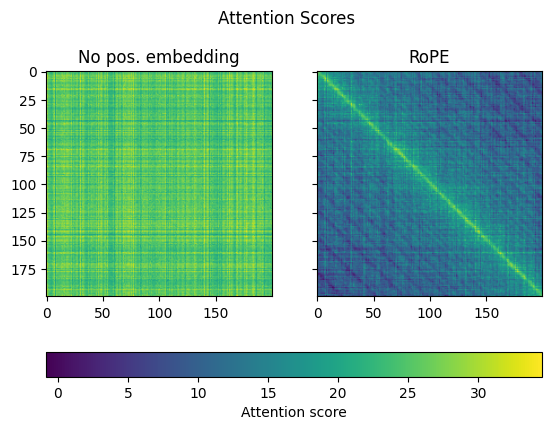

In [49]:

import matplotlib.colorizer as mcolorizer
import matplotlib.colors as mcolors

fig, axs = plt.subplots(1, 2, sharey=True)


# create a colorizer with a predefined norm to be shared across all images
norm = mcolors.Normalize(
    vmin=min(torch.min(attention_scores), torch.min(attention_scores_)),
    vmax=max(torch.max(attention_scores), torch.max(attention_scores_))
)

colorizer = mcolorizer.Colorizer(norm=norm)


s = axs[0].imshow(
    attention_scores[0, 0,...], colorizer=colorizer
)
axs[1].imshow(
    attention_scores_[0, 0,...], colorizer=colorizer
)

# axs[0].set_xlabel('Token id')
# axs[1].set_xlabel('Token id')
# axs[0].set_ylabel('Token id')

axs[0].set_title('No pos. embedding')
axs[1].set_title('RoPE')
fig.suptitle('Attention Scores', y=0.9)
fig.colorbar(s, ax=axs, orientation='horizontal', fraction=.1, label='Attention score')


When plotting up the attention scores calculated from $q$ and $k$ tensors without positional embedding (left had side), we only see random horizontal and vertical lines stemming from the random initialization of the $q$ and $k$ tensors. There is no sign of positional "awareness". In contrast, for the attention scores calculated from $q\_$ and $k\_$ tensors to which we have applied rotational position embedding, we do see a very clear diagonal line which indicates strong positional "awareness", i.e. tokens closer in the sequence attends to the query token with much stronger weigths than those further away.